### 2.1 理论计算题

1.  输出特征图尺寸

输入图像尺寸：通道数3，高32，宽32  
卷积层参数：16个卷积核，卷积核大小5×5，填充P=2，步幅S=2  

输出高：
$$
H_{out} = \frac{H_{in} + 2P - K}{S} + 1 = \frac{32 + 2 \times 2 - 5}{2} + 1 = 16
$$

输出宽：
$$
W_{out} = \frac{W_{in} + 2P - K}{S} + 1 = \frac{32 + 2 \times 2 - 5}{2} + 1 = 16
$$

输出通道数等于卷积核数量，为16。

输出特征图尺寸：16 × 16 × 16



2.  单个输出通道像素点的点乘次数

卷积核尺寸为3 × 5 × 5，点乘次数等于卷积核的参数数量：
$$
3 \times 5 \times 5 = 75
$$

单个输出通道的一个像素值，需要75次点乘操作。


### 2.2 编程题


输入特征图：
[[6 3 7 4 6 9]
 [2 6 7 4 3 7]
 [7 2 5 4 1 7]
 [5 1 4 0 9 5]
 [8 0 9 2 6 3]
 [8 2 4 2 6 4]]

池化后输出：
[[6. 7. 9.]
 [7. 5. 9.]
 [8. 9. 6.]]


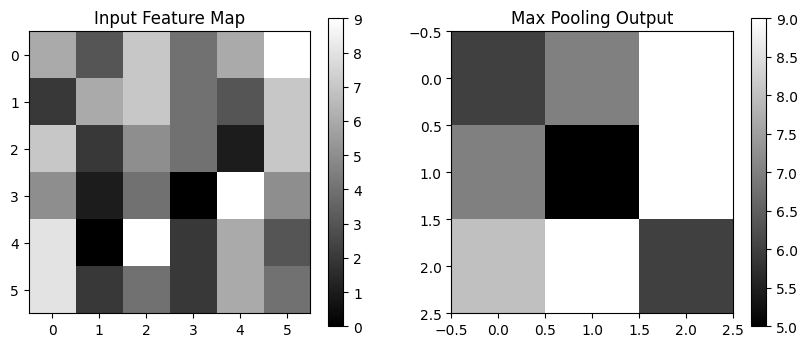

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def max_pool2d_forward(x, kernel_size, stride=1, padding=0):
    """
    手动实现二维最大池化前向传播
    参数：
        x: 输入特征图，形状为 (N, C, H, W)
        kernel_size: 池化核大小 (k_h, k_w)
        stride: 步幅 (s_h, s_w)
        padding: 填充 (p_h, p_w)
    返回：
        out: 池化后的输出特征图
    """
    N, C, H, W = x.shape
    k_h, k_w = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
    s_h, s_w = stride if isinstance(stride, tuple) else (stride, stride)
    p_h, p_w = padding if isinstance(padding, tuple) else (padding, padding)
    
    # 计算输出尺寸
    out_h = (H + 2 * p_h - k_h) // s_h + 1
    out_w = (W + 2 * p_w - k_w) // s_w + 1
    
    # 对输入进行填充
    x_pad = np.pad(x, ((0,0), (0,0), (p_h,p_h), (p_w,p_w)), mode='constant')
    
    # 初始化输出
    out = np.zeros((N, C, out_h, out_w))
    
    # 滑动窗口遍历
    for i in range(out_h):
        for j in range(out_w):
            # 窗口在输入中的位置
            h_start = i * s_h
            h_end = h_start + k_h
            w_start = j * s_w
            w_end = w_start + k_w
            
            # 取窗口区域并求最大值
            window = x_pad[:, :, h_start:h_end, w_start:w_end]
            out[:, :, i, j] = np.max(window, axis=(2,3))
    
    return out

# 测试代码 
if __name__ == "__main__":
    # 构造测试输入
    np.random.seed(42)
    x = np.random.randint(0, 10, size=(1, 1, 6, 6))  # N=1, C=1, H=6, W=6
    print("输入特征图：")
    print(x[0,0])
    
    # 池化参数
    kernel_size = 2
    stride = 2
    padding = 0
    
    # 手动实现池化
    out = max_pool2d_forward(x, kernel_size, stride, padding)
    print("\n池化后输出：")
    print(out[0,0])
    
    # 可视化
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.title("Input Feature Map")
    plt.imshow(x[0,0], cmap='gray')
    plt.colorbar()
    
    plt.subplot(1,2,2)
    plt.title("Max Pooling Output")
    plt.imshow(out[0,0], cmap='gray')
    plt.colorbar()
    plt.show()

### 3.1 理论计算题

1.  单个 $5\times5$ 卷积层（不带偏置）的参数量
输入通道数为 $C$，输出通道数为 $C$，卷积核大小为 $5\times5$。
参数量 = 输入通道数 × 输出通道数 × 卷积核高 × 卷积核宽
$$
C \times C \times 5 \times 5 = 25C^2
$$

2.  两个串联的 $3\times3$ 卷积层（不带偏置）的总参数量
第一层：输入通道数 $C$，输出通道数 $C$，参数量为 $C \times C \times 3 \times 3 = 9C^2$
第二层：输入通道数 $C$，输出通道数 $C$，参数量为 $C \times C \times 3 \times 3 = 9C^2$
总参数量：
$$
9C^2 + 9C^2 = 18C^2
$$

### 3.2 编程题


In [3]:
import torch
import torch.nn as nn

class NiNBlock(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(NiNBlock, self).__init__(
            # 主卷积层
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(inplace=True),
            # 两个 1x1 卷积层
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(inplace=True)
        )

# 测试代码
if __name__ == "__main__":
    # 构造一个 NiN 块，输入通道 3，输出通道 96，卷积核 11x11，步幅 4，填充 0
    nin_block = NiNBlock(in_channels=3, out_channels=96, kernel_size=11, stride=4, padding=0)
    print(nin_block)
    
    # 测试前向传播
    x = torch.randn(1, 3, 224, 224)
    out = nin_block(x)
    print("输入尺寸:", x.shape)
    print("输出尺寸:", out.shape)

NiNBlock(
  (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
  (1): ReLU(inplace=True)
  (2): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU(inplace=True)
  (4): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
  (5): ReLU(inplace=True)
)
输入尺寸: torch.Size([1, 3, 224, 224])
输出尺寸: torch.Size([1, 96, 54, 54])


### 4.1 理论计算题

首先，计算小批量均值：
$$
\mu = \frac{2 + 4 + 6 + 8}{4} = 5
$$

计算方差：
$$
\sigma^2 = \frac{(2-5)^2 + (4-5)^2 + (6-5)^2 + (8-5)^2}{4} = \frac{9 + 1 + 1 + 9}{4} = 5
$$

批量归一化公式为：
$$
y_i = \gamma \cdot \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta
$$

代入参数 $\gamma=2, \beta=1, \epsilon=0$：

- $y_1 = 2 \cdot \frac{2-5}{\sqrt{5}} + 1 = 1 - \frac{6}{\sqrt{5}}$
- $y_2 = 2 \cdot \frac{4-5}{\sqrt{5}} + 1 = 1 - \frac{2}{\sqrt{5}}$
- $y_3 = 2 \cdot \frac{6-5}{\sqrt{5}} + 1 = 1 + \frac{2}{\sqrt{5}}$
- $y_4 = 2 \cdot \frac{8-5}{\sqrt{5}} + 1 = 1 + \frac{6}{\sqrt{5}}$

（或近似小数形式：$y_1 \approx -1.683, y_2 \approx 0.106, y_3 \approx 1.894, y_4 \approx 3.683$）

### 4.2 编程题


In [4]:
import torch
import torch.nn as nn

class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super(Residual, self).__init__()
        # 两个3×3卷积层，每层后跟批量归一化
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 1x1卷积层，用于调整输入通道数和形状
        if use_1x1conv:
            self.conv3 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        else:
            self.conv3 = None

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x

        # 主路径
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # 调整残差路径
        if self.conv3 is not None:
            identity = self.conv3(x)

        # 残差连接
        out += identity
        out = self.relu(out)
        return out

# 测试代码
if __name__ == "__main__":
    # 输入：batch_size=1, channels=3, height=64, width=64
    x = torch.randn(1, 3, 64, 64)
    
    # 无1x1卷积的残差块
    residual_block1 = Residual(3, 3)
    out1 = residual_block1(x)
    print("无1x1卷积时输入输出形状：", x.shape, out1.shape)

    # 有1x1卷积的残差块（通道数变化、步幅变化）
    residual_block2 = Residual(3, 6, use_1x1conv=True, stride=2)
    out2 = residual_block2(x)
    print("有1x1卷积时输入输出形状：", x.shape, out2.shape)

无1x1卷积时输入输出形状： torch.Size([1, 3, 64, 64]) torch.Size([1, 3, 64, 64])
有1x1卷积时输入输出形状： torch.Size([1, 3, 64, 64]) torch.Size([1, 6, 32, 32])


### 5.1 理论计算题

1.  底层特征提取层在大型源数据集上预训练完成，已经学习到了通用的边缘、纹理等基础视觉特征，这些特征对目标任务依然有效。如果用较大的学习率更新，容易破坏这些已经学到的通用特征，导致模型在源数据集上的性能“遗忘”，不利于迁移学习。因此需要设置较小的学习率，甚至冻结参数，只对其进行微调。
顶层输出层是为新任务随机初始化的，没有任何先验知识，需要快速学习目标数据集的特定类别分布，因此设置较大的学习率，让它更快地适应新任务。



2. 当目标数据集很小且与源数据集非常相似时，为防止过拟合，可以采用以下策略: 
①冻结大部分底层网络，仅训练最后几层分类层，避免过多参数在小数据上过拟合。
②使用更小的学习率，只对顶层进行微调，减少参数更新幅度。
③增加 Dropout、权重衰减等正则化手段，抑制模型对噪声的拟合。
④对目标数据进行图像增广，扩充数据量，提高数据多样性。

### 5.2 编程题


增广前图像尺寸: (300, 300)
增广后张量形状: torch.Size([3, 224, 224])
张量像素值范围: min=0.678, max=0.965


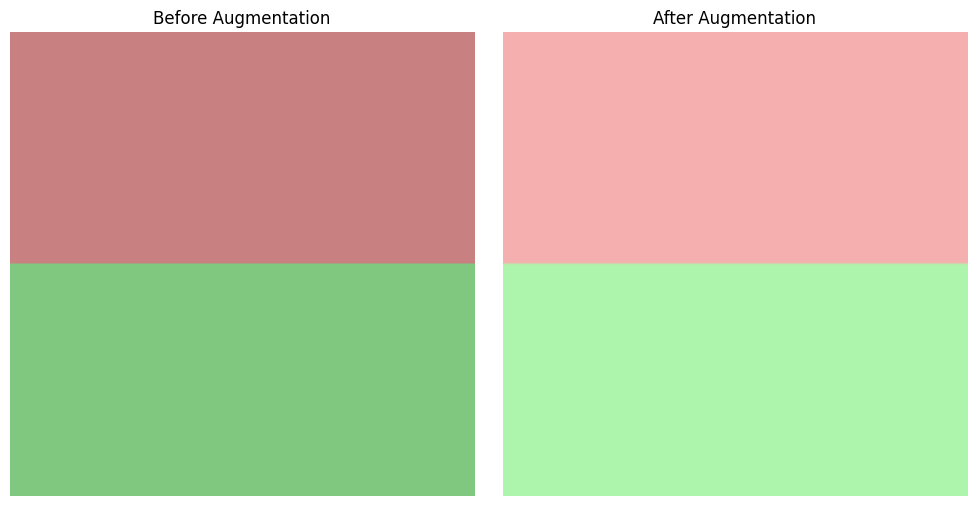

In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# 定义图像增广管道 
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        size=224,
        scale=(0.08, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.5
    ),
    transforms.ToTensor()
])

# -构造一张示例图像
# 生成一张纯色测试图
import numpy as np
img_np = np.ones((300, 300, 3), dtype=np.uint8) * 128
img_np[:150, :, 0] = 200  # 上半部分偏红
img_np[150:, :, 1] = 200  # 下半部分偏绿
img = Image.fromarray(img_np)



# 应用增广并验证输出 
print("增广前图像尺寸:", img.size)

# 应用增广
img_tensor = train_transform(img)

print("增广后张量形状:", img_tensor.shape)
print("张量像素值范围:", 
      f"min={img_tensor.min().item():.3f}, max={img_tensor.max().item():.3f}")

# 可视化增广前后对比 
def tensor_to_pil(tensor):
    return transforms.ToPILImage()(tensor)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Before Augmentation")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("After Augmentation")
plt.imshow(tensor_to_pil(img_tensor))
plt.axis('off')

plt.tight_layout()
plt.show()

### 6.1 理论计算题

首先，确定两个边界框的交集区域：

- 交集左上角坐标：
  $x_{max1} = \max(10, 30) = 30$
  $y_{max1} = \max(10, 30) = 30$

- 交集右下角坐标：
  $x_{min2} = \min(50, 70) = 50$
  $y_{min2} = \min(50, 70) = 50$

交集区域的宽和高：
$w = 50 - 30 = 20$
$h = 50 - 30 = 20$

交集面积：
$$
Area_{intersection} = 20 \times 20 = 400
$$

分别计算两个框的面积：
$$
Area_A = (50-10) \times (50-10) = 40 \times 40 = 1600
$$
$$
Area_B = (70-30) \times (70-30) = 40 \times 40 = 1600
$$

并集面积：
$$
Area_{union} = Area_A + Area_B - Area_{intersection} = 1600 + 1600 - 400 = 2800
$$

交并比 IoU：
$$
IoU = \frac{Area_{intersection}}{Area_{union}} = \frac{400}{2800} = \frac{1}{7}
$$



### 6.2 编程题


In [9]:
import torch
import torch.nn as nn

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing

    def forward(self, inputs, targets):
        """
        inputs: 模型输出的logits，形状 [N, K]，未经过softmax
        targets: 真实标签，形状 [N]，元素是类别索引
        """
        K = inputs.size(-1)
        # 转换为概率分布
        log_probs = nn.LogSoftmax(dim=-1)(inputs)
        
        # 构造平滑后的标签分布
        true_dist = torch.zeros_like(log_probs)
        true_dist.fill_(self.smoothing / (K - 1))
        true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        
        # 计算交叉熵
        loss = (-true_dist * log_probs).sum(dim=-1).mean()
        return loss

# 测试
if __name__ == "__main__":
    # 模拟一个batch，N=3个样本，K=5分类
    N, K = 3, 5
    logits = torch.randn(N, K)
    targets = torch.tensor([0, 2, 4])  # 真实类别

    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
    loss = criterion(logits, targets)

    print("模型输出logits:\n", logits)
    print("真实标签:", targets)
    print("Label Smoothing Cross Entropy Loss:", loss.item())

模型输出logits:
 tensor([[-0.3866, -0.9607,  1.6351,  1.5297,  0.2433],
        [ 0.3650,  1.4247,  0.1848, -0.2154,  0.0221],
        [-1.9186,  2.8755, -0.2822,  1.8661,  0.9513]])
真实标签: tensor([0, 2, 4])
Label Smoothing Cross Entropy Loss: 2.3762917518615723
